In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)


Running on: cpu


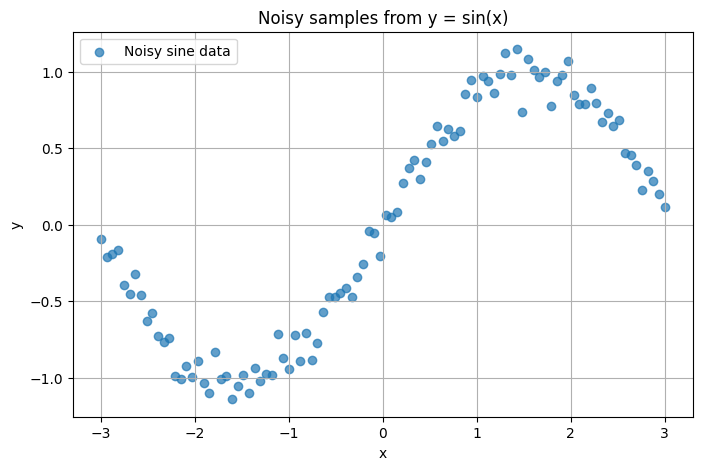

Step  20 | Loss: 0.2600 | w: 0.2032 | b: -0.0315
Step  40 | Loss: 0.2008 | w: 0.3006 | b: -0.0245
Step  60 | Loss: 0.1960 | w: 0.3282 | b: -0.0198
Step  80 | Loss: 0.1955 | w: 0.3360 | b: -0.0167
Step 100 | Loss: 0.1955 | w: 0.3382 | b: -0.0146
Step 120 | Loss: 0.1955 | w: 0.3388 | b: -0.0132
Step 140 | Loss: 0.1955 | w: 0.3390 | b: -0.0123
Step 160 | Loss: 0.1955 | w: 0.3390 | b: -0.0116
Step 180 | Loss: 0.1955 | w: 0.3390 | b: -0.0112
Step 200 | Loss: 0.1955 | w: 0.3390 | b: -0.0109


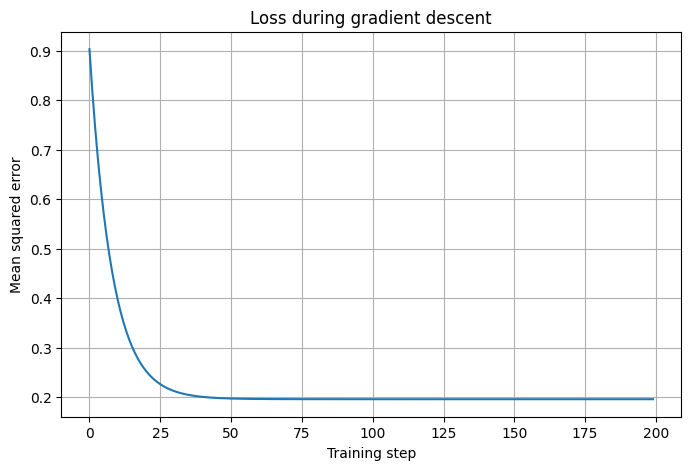

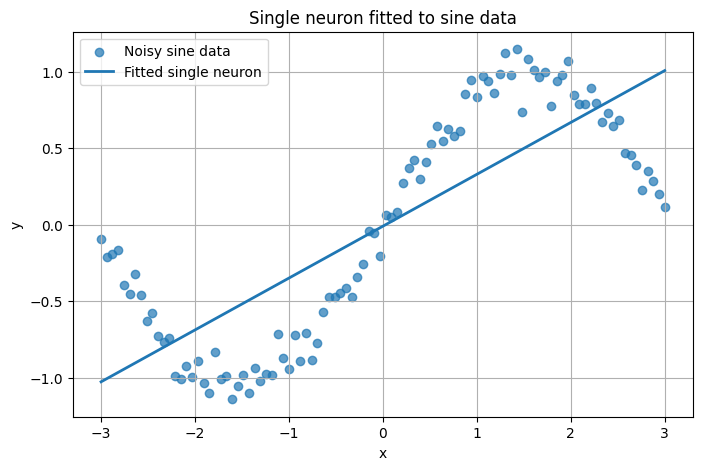

Final weight: 0.3390312757270389
Final bias: -0.010941835786772039
Final loss: 0.19545212040311394


In [2]:
# Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Noisy sine data", alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy samples from y = sin(x)")
plt.legend()
plt.grid(True)
plt.show()

# Initialise parameters
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# Training settings
lr = 0.01
steps = 200
losses = []

# Gradient-descent loop
for step in range(steps):
    # Forward pass
    y_hat = w * x + b

    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Parameter updates
    w -= lr * dw
    b -= lr * db

    if (step + 1) % 20 == 0:
        print(
            f"Step {step + 1:3d} | "
            f"Loss: {loss:.4f} | "
            f"w: {w:.4f} | "
            f"b: {b:.4f}"
        )

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Mean squared error")
plt.title("Loss during gradient descent")
plt.grid(True)
plt.show()

# Final predictions
final_predictions = w * x + b

# Plot final fit
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Noisy sine data", alpha=0.7)
plt.plot(x, final_predictions, linewidth=2, label="Fitted single neuron")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single neuron fitted to sine data")
plt.legend()
plt.grid(True)
plt.show()

print("Final weight:", w)
print("Final bias:", b)
print("Final loss:", losses[-1])